# langchin_google_genai
- gemini 활용 시 사용하는 langchain 라이브러리
- ChatGoogleGenerativeAI 라이브러리의 model에 사용하고자 하는 모델 명을 기입, api_key의 경우 기입하지 않아도 GEMINI_API_KEY 환경변수의 값을 가져와 사용

In [32]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", api_key=os.getenv("GEMINI_API_KEY"))

# API를 통한 검색 방법
- BaseModel 활용 : 필드를 넣어 답변 스키마를 지정 
    - TypedDict는 BaseModel보다 낮은 검증
    - Field는 BaseModel의 필드에 description을 추가하는데 Langchain에서는 description을 통해 '어떤 답변을 넣어야 하는지' 알려주는 안내문 역할을 한다.
- invoke()를 통해 답변을 받는다. 

In [33]:
from pydantic import BaseModel, Field
class SearchQuery(BaseModel) : 
    search_query: str = Field(None, description = "검색어")
    justification : str = Field(None, description= "why this query is relevant to the user question")
    
structured_llm = llm.with_structured_output(SearchQuery) 

output = structured_llm.invoke("What is the capital of South Korea and why do you think this is the answer?")
print(output.search_query)
print(output.justification)

capital of South Korea
The user is asking for the capital city of a specific country, which is a factual query that requires verifying the administrative center of South Korea.


# tool calling
- bind_tools를 통해 여러 tool들을 등록시킬 수 있는데 기존과 다른점은 invoke를 통해 구성된 답을 받는것이 아닌 어떤 메서드를 활용해야 할 지 return 받는다. (인자 생성 포함)
- tool calling과 상관 없는 질문 시 일반 답변이 나온다. ("안녕?" > "안녕하세요?")


In [34]:
def multiply(a: int, b: int) -> int : 
    """ Multiplies two numbers together."""
    return a * b

llm_with_tools = llm.bind_tools([multiply])

msg = llm_with_tools.invoke("What is 2 times 3?")

msg

AIMessage(content=[], additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'}, '__gemini_function_call_thought_signatures__': {'6b838a39-b456-44cf-834e-7f680abb38c1': 'EjQKMgEMOdbHXPVnNO4zgm/EvTOrNiWhjYhUISOw3YdO5VH8VHxNnLjUVjkyabdhZdVlckTX'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e3218-7bc1-7802-8c5a-d709e2b57fa4-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': '6b838a39-b456-44cf-834e-7f680abb38c1', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 63, 'output_tokens': 16, 'total_tokens': 79, 'input_token_details': {'cache_read': 0}})

In [35]:
def multiply(a: int, b: int) -> int : 
    """ Multiplies two numbers together."""
    return a * b

llm_with_tools = llm.bind_tools([multiply])

msg = llm_with_tools.invoke("안녕?")

msg

AIMessage(content=[{'type': 'text', 'text': '안녕하세요! 만나서 반가워요. 오늘 어떤 도움을 드릴까요?', 'extras': {'signature': 'EjQKMgEMOdbH9r3QTRU8buqwpoJLIgSDEQjqRZ0bG5HyekbhKq3ZVJjvUF/zKeC1uDeQymHd'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e3218-8fc9-7513-98f5-3d1c2370ab3b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 58, 'output_tokens': 16, 'total_tokens': 74, 'input_token_details': {'cache_read': 0}})

# condition(조건)에 따라 분기되는 workflow
- anthropic api를 활용하는 영상에선 응답값을 msg.content를 통해 받아왔는데 gemini의 경우 그렇게 받아오면 예상한 타입과 다르게 받아오기 때문에 안된다. (리스트로 가져옴, 멀티모델이라 그런가 ) 쨋든 그래서 text로 가져와야함

In [58]:
from typing_extensions import TypedDict
# Graph State
class State(TypedDict) : 
    topic: str
    joke: str
    improve_joke: str
    final_joke: str

In [65]:
# Nodes
def generate_joke(state: State) -> str : 
    """ Generate a joke about the given topic. """
    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {'joke': msg.text}


def improve_joke(state: State) -> str: 
    """ Second LLM call to improve the joke """
    msg = llm.invoke(f"Improve the following joke: {state['joke']}")
    return {'improve_joke': msg.text}   


def polish_joke(state: State) -> str : 
    """ Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surpring twist to this joke: {state['improve_joke']}")
    return {'final_joke': msg.text}

# Conditional edge function to check if the joke has a punchline
def check_punchline(state : State) -> bool : 
    """ Check if the joke has a punchline. """
    
    # Simple check - does the joke contain "?" or "!"
    if "?" in state["joke"] or "!" in state["joke"] : 
        return "Pass"
    return "Fail"
    

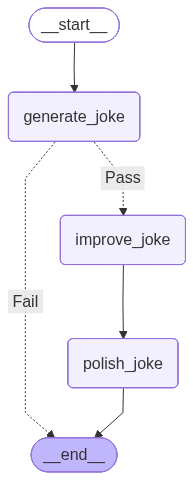

In [66]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Build Workflow
workflow = StateGraph(State) 

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke) 

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges("generate_joke", 
                               check_punchline,
                               {"Pass" : "improve_joke", "Fail" : END})
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
chain = workflow.compile()

# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))

In [ ]:
state = chain.invoke({"topic": "cats"})
print(state['joke'])
if "improve_joke" in state : 
    print(" The joke had a punchline, so it was improved. ")
    print(state['improve_joke'])
    
    print(" The improved joke was polished with a surprising twist. ")
    print(state['final_joke'])
else :  
    print("The joke did not have a punchline, so it was not improved.")


Why was the cat sitting on the computer?

Because he wanted to keep an eye on the **mouse**!
 The joke had a punchline, so it was improved. 
To improve this joke, you can play more on the dual meanings of "mouse" (the animal vs. the computer peripheral) or incorporate more "cat-like" behaviors.

Here are a few ways to punch it up:

**Option 1: The "Tech Support" angle (Relatable)**
> "Why was the cat sitting on the computer?"
> "He heard it had a mouse, and he wanted to make sure it didn’t get away."

**Option 2: The "Literal" angle (Dry humor)**
> "Why was the cat sitting on the computer?"
> "He was just trying to keep an eye on the mouse. He’s been waiting for it to move for three hours."

**Option 3: The "Punny" angle (Snappier)**
> "Why was the cat sitting on the computer?"
> "To keep his mouse close, but his enemies closer."

**Option 4: Short and punchy (Best for social media)**
> "Why was the cat sitting on the computer?"
> "He was hunting for a mouse. Turns out, it was just a c

# Orchestrator-Worker

In [ ]:
from pydantic import BaseModel, Field
from typing import Annotated, List
import operator

# Schema for structured output to use in plannging
class Section(BaseModel) : 
    name: str = Field(description="Name for this section of the report")
    description: str = Field(description="Brief overview of the main topics and concepts to be covered in this section. ")

class Sections(BaseModel) : 
    sections: List[Section] = Field(description="Sections for the report")

# Augment the LLM with schema for structured output
planner = llm.with_structured_output(Sections)

In [ ]:
# Graph state
class State(TypedDict) : 
    topic: str
    sections: List[Section]
    completed_sections: Annotated[
        list, operator.add
    ]
    final_report: str
    
# Worker state
class WorkerState(TypedDict) : 
    section : Section
    completed_sections: Annotated[list, operator.add]

In [ ]:
def orchestrator(state: State) : 
    """Orchestrator that generates a plan for the report"""
    
    # Generate queries
    